# 🎬 Movie Recomandation System
**Data Mining (3160714) | CIPAT Mini Project**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')



## Load Dataset


In [ ]:
import pandas as pd

movies_url = "https://drive.google.com/uc?id=1-1n6MTOQelT-r_xw0T95H_Kk7fmi3-pS"
credits_url = "https://drive.google.com/uc?id=14WgD7X23xHRJexm0U_Nwyz9ZB5SqyjBU"

movies = pd.read_csv(movies_url)
credits = pd.read_csv(credits_url)

In [ ]:
movies.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [ ]:
credits.head(3)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [ ]:
movies.shape

(4803, 20)

In [ ]:
credits.shape

(4803, 4)

##Merged To Dataset ( Movies, Creadits)

In [ ]:
movies = movies.merge(credits, on="title")

In [ ]:
movies.head(2)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [ ]:
movies.shape

(4809, 23)

In [ ]:
movies['original_language'].value_counts()

,count
original_language,
en,4510
fr,70
es,32
zh,27
de,27
hi,19
ja,16
it,14
ko,12


In [ ]:
movies.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'movie_id', 'cast', 'crew'],
      dtype='object')

## Features Extracting

In [ ]:
movies = movies[['movie_id','original_title','title','overview','genres','keywords',
                 'cast','crew','vote_average','vote_count','revenue']]

In [ ]:
movies.head(2)

,movie_id,original_title,title,overview,genres,keywords,cast,crew,vote_average,vote_count,revenue
0,19995,Avatar,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,2787965087
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,961000000


In [ ]:
movies.shape

(4809, 11)

In [ ]:
movies.isnull().sum()

,0
movie_id,0
original_title,0
title,0
overview,3
genres,0
keywords,0
cast,0
crew,0
vote_average,0
vote_count,0


## Preprocessing

In [ ]:
movies.dropna(inplace=True)

In [ ]:
movies.isnull().sum()

,0
movie_id,0
original_title,0
title,0
overview,0
genres,0
keywords,0
cast,0
crew,0
vote_average,0
vote_count,0


In [ ]:
movies.shape

(4806, 11)

In [ ]:
movies.duplicated().sum()

np.int64(0)

In [ ]:
movies.iloc[0]['genres']

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [ ]:
#Example that show how ast.literal_eval('') help to convert string to list
import ast
ast.literal_eval('[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]')

[{'id': 28, 'name': 'Action'},
 {'id': 12, 'name': 'Adventure'},
 {'id': 14, 'name': 'Fantasy'},
 {'id': 878, 'name': 'Science Fiction'}]

In [ ]:
import ast
def convert(obj):
    L = []
    for i in ast.literal_eval(obj):
      L.append(i['name'])
    return L

In [ ]:
movies['genres'].apply(convert)

,genres
0,"[Action, Adventure, Fantasy, Science Fiction]"
1,"[Adventure, Fantasy, Action]"
2,"[Action, Adventure, Crime]"
3,"[Action, Crime, Drama, Thriller]"
4,"[Action, Adventure, Science Fiction]"
...,...
4804,"[Action, Crime, Thriller]"
4805,"[Comedy, Romance]"
4806,"[Comedy, Drama, Romance, TV Movie]"
4807,[]


In [ ]:
movies['genres'] = movies['genres'].apply(convert)

In [ ]:
movies.head(2)

,movie_id,original_title,title,overview,genres,keywords,cast,crew,vote_average,vote_count,revenue
0,19995,Avatar,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,2787965087
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,961000000


In [ ]:
movies.iloc[0]['keywords']

'[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]'

In [ ]:
movies['keywords'] = movies['keywords'].apply(convert)
movies.head(2)

,movie_id,original_title,title,overview,genres,keywords,cast,crew,vote_average,vote_count,revenue
0,19995,Avatar,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,2787965087
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,961000000


In [ ]:
movies.iloc[0]['cast']

'[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "credit_id": "52fe48009251416c750ac9cf", "gender": 2, "id": 32747, "name": "Stephen Lang", "order": 3}, {"cast_id": 5, "character": "Trudy Chacon", "credit_id": "52fe48009251416c750ac9d3", "gender": 1, "id": 17647, "name": "Michelle Rodriguez", "order": 4}, {"cast_id": 8, "character": "Selfridge", "credit_id": "52fe48009251416c750ac9e1", "gender": 2, "id": 1771, "name": "Giovanni Ribisi", "order": 5}, {"cast_id": 7, "character": "Norm Spellman", "credit_id": "52fe48009251416c750ac9dd", "gender": 

In [ ]:
def convert_cast(obj):
    L = []
    counter = 0
    for i in ast.literal_eval(obj):
      if counter <= 3:
          L.append(i['name'])
      counter += 1
    return L

In [ ]:
movies['cast'] = movies['cast'].apply(convert_cast)
movies.head()

,movie_id,original_title,title,overview,genres,keywords,cast,crew,vote_average,vote_count,revenue
0,19995,Avatar,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,2787965087
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,961000000
2,206647,Spectre,Spectre,A cryptic message from Bond’s past sends him o...,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi...","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3,4466,880674609
3,49026,The Dark Knight Rises,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret i...","[Christian Bale, Michael Caine, Gary Oldman, A...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6,9106,1084939099
4,49529,John Carter,John Carter,"John Carter is a war-weary, former military ca...","[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel...","[Taylor Kitsch, Lynn Collins, Samantha Morton,...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1,2124,284139100


In [ ]:
movies.iloc[0]['crew']

'[{"credit_id": "52fe48009251416c750aca23", "department": "Editing", "gender": 0, "id": 1721, "job": "Editor", "name": "Stephen E. Rivkin"}, {"credit_id": "539c47ecc3a36810e3001f87", "department": "Art", "gender": 2, "id": 496, "job": "Production Design", "name": "Rick Carter"}, {"credit_id": "54491c89c3a3680fb4001cf7", "department": "Sound", "gender": 0, "id": 900, "job": "Sound Designer", "name": "Christopher Boyes"}, {"credit_id": "54491cb70e0a267480001bd0", "department": "Sound", "gender": 0, "id": 900, "job": "Supervising Sound Editor", "name": "Christopher Boyes"}, {"credit_id": "539c4a4cc3a36810c9002101", "department": "Production", "gender": 1, "id": 1262, "job": "Casting", "name": "Mali Finn"}, {"credit_id": "5544ee3b925141499f0008fc", "department": "Sound", "gender": 2, "id": 1729, "job": "Original Music Composer", "name": "James Horner"}, {"credit_id": "52fe48009251416c750ac9c3", "department": "Directing", "gender": 2, "id": 2710, "job": "Director", "name": "James Cameron"},

In [ ]:
import ast

def fetch_director(obj):
    L = []
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            L.append(i['name'])
            break
    return L

In [ ]:
movies['crew'] = movies['crew'].apply(fetch_director)
movies.head(2)

,movie_id,original_title,title,overview,genres,keywords,cast,crew,vote_average,vote_count,revenue
0,19995,Avatar,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron],7.2,11800,2787965087
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",[Gore Verbinski],6.9,4500,961000000


In [ ]:
movies['overview'] = movies['overview'].apply(lambda x:x.split())
movies.head(2)

,movie_id,original_title,title,overview,genres,keywords,cast,crew,vote_average,vote_count,revenue
0,19995,Avatar,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weave...",[James Cameron],7.2,11800,2787965087
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",[Gore Verbinski],6.9,4500,961000000


In [ ]:
#Sam Worthington
#SamWorthington

def remove_space(word):
    L1 = []
    for i in word:
      L1.append(i.replace(" ",""))
    return L1

In [ ]:
movies['cast'] = movies['cast'].apply(remove_space)
movies['crew'] = movies['crew'].apply(remove_space)
movies['genres'] = movies['genres'].apply(remove_space)
movies['keywords'] = movies['keywords'].apply(remove_space)

In [ ]:
movies.head(2)

,movie_id,original_title,title,overview,genres,keywords,cast,crew,vote_average,vote_count,revenue
0,19995,Avatar,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver, ...",[JamesCameron],7.2,11800,2787965087
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley, Ste...",[GoreVerbinski],6.9,4500,961000000


## EDA charts

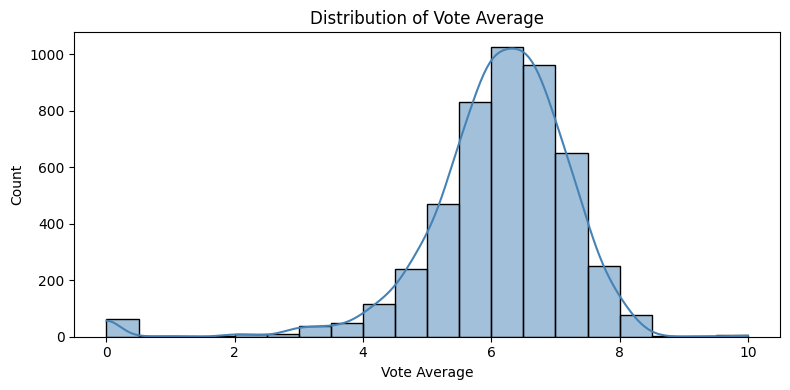

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(movies['vote_average'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Vote Average')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

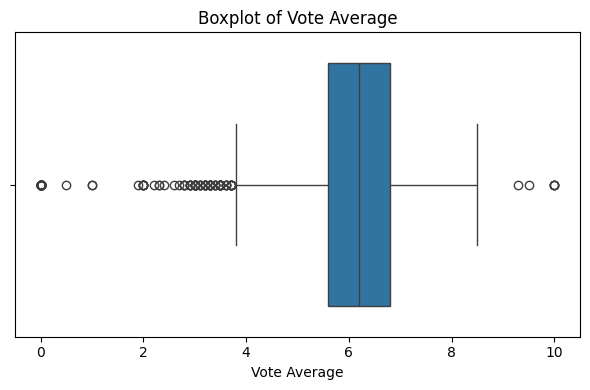

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=movies['vote_average'])
plt.title('Boxplot of Vote Average')
plt.xlabel('Vote Average')
plt.tight_layout()
plt.show()

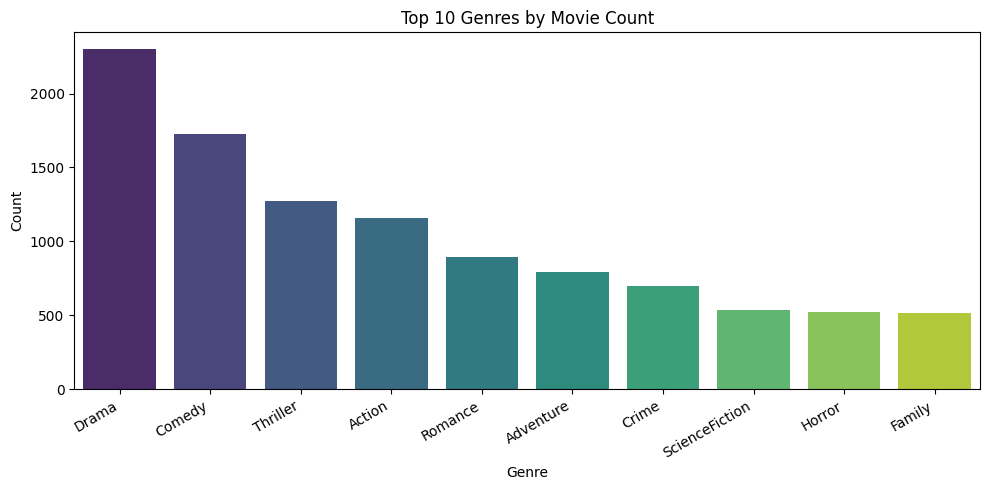

In [ ]:
from collections import Counter

all_genres = []
for g in movies['genres']:
    if isinstance(g, list):
        all_genres.extend(g)          # already a list
    else:
        all_genres.extend(ast.literal_eval(g))  # still a string

genre_counts = Counter(all_genres).most_common(10)
genre_df = pd.DataFrame(genre_counts, columns=['Genre', 'Count'])

plt.figure(figsize=(10,5))
sns.barplot(data=genre_df, x='Genre', y='Count', palette='viridis')
plt.title('Top 10 Genres by Movie Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

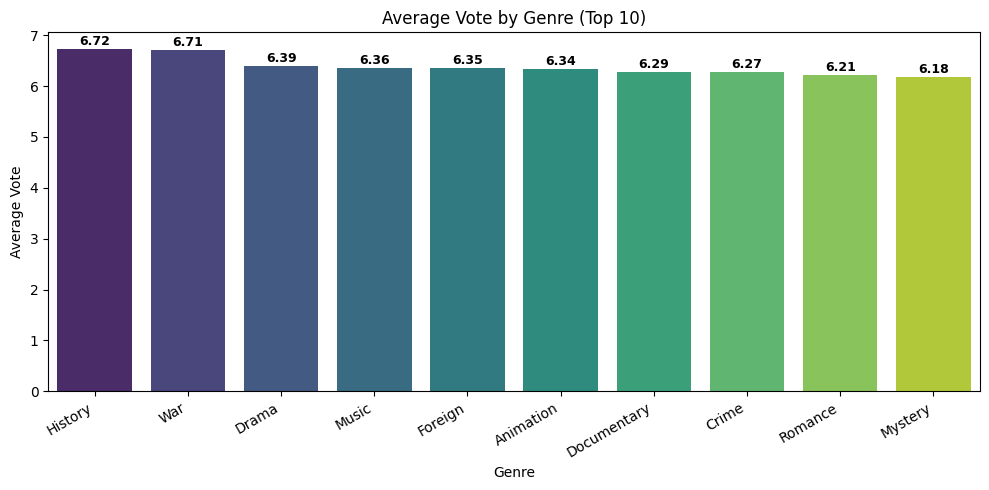

In [ ]:
exploded = movies.explode('genres')
genre_avg = exploded.groupby('genres')['vote_average'].mean().sort_values(ascending=False).head(10).reset_index()
genre_avg.columns = ['Genre', 'Avg Vote']

plt.figure(figsize=(10,5))
bars = sns.barplot(data=genre_avg, x='Genre', y='Avg Vote', palette='viridis')

for bar, val in zip(bars.patches, genre_avg['Avg Vote']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Average Vote by Genre (Top 10)')
plt.xlabel('Genre')
plt.ylabel('Average Vote')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

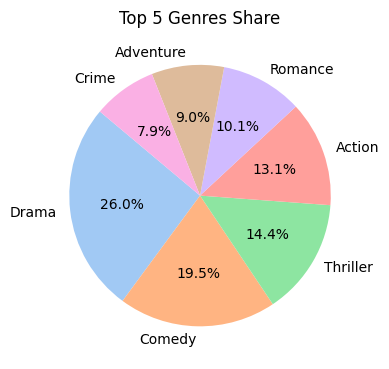

In [ ]:
top5 = genre_df.head(7)
plt.figure(figsize=(4,4))
plt.pie(top5['Count'], labels=top5['Genre'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Top 5 Genres Share')
plt.tight_layout()
plt.show()

## Apriori Algorithm

In [ ]:
!pip install mlxtend

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import MultiLabelBinarizer

In [ ]:
transactions = movies['genres'] + movies['keywords']
transactions.head()

,0
0,"[Action, Adventure, Fantasy, ScienceFiction, c..."
1,"[Adventure, Fantasy, Action, ocean, drugabuse,..."
2,"[Action, Adventure, Crime, spy, basedonnovel, ..."
3,"[Action, Crime, Drama, Thriller, dccomics, cri..."
4,"[Action, Adventure, ScienceFiction, basedonnov..."


In [ ]:
mlb = MultiLabelBinarizer()
encoded_data = mlb.fit_transform(transactions)

df_apriori = pd.DataFrame(encoded_data, columns=mlb.classes_)
df_apriori.head()

,15thcentury,16thcentury,17thcentury,18thcentury,1910s,1920s,1930s,1940s,1950s,1960s,...,flippingcoin,gilbertandsullivan,nightgown,northcarolinam,nosferatu,strangenoise,Γη,卧底肥妈,绝地奶霸,超级妈妈
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
frequent_items = apriori(df_apriori, min_support=0.05, use_colnames=True)

frequent_items.head()

,support,itemsets
0,0.240533,(Action)
1,0.164794,(Adventure)
2,0.358510,(Comedy)
3,0.145027,(Crime)
4,0.478360,(Drama)


In [ ]:
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.5)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Adventure),(Action),0.164794,0.240533,0.096962,0.588384,2.446170,1.0,0.057324,1.845086,0.707847,0.314440,0.458020,0.495749
1,(ScienceFiction),(Action),0.111943,0.240533,0.057844,0.516729,2.148268,1.0,0.030918,1.571513,0.601886,0.196328,0.363671,0.378607
2,(Family),(Comedy),0.106950,0.358510,0.062422,0.583658,1.628008,1.0,0.024079,1.540775,0.431949,0.154879,0.350976,0.378886
3,(Romance),(Comedy),0.186226,0.358510,0.100707,0.540782,1.508415,1.0,0.033944,1.396918,0.414184,0.226804,0.284138,0.410844
4,(Crime),(Drama),0.145027,0.478360,0.079276,0.546628,1.142713,1.0,0.009901,1.150579,0.146074,0.145698,0.130872,0.356176


In [ ]:
rules = rules.sort_values(by='confidence', ascending=False)
rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
8,(Mystery),(Thriller),0.072409,0.265293,0.050354,0.695402,2.621258,1.0,0.031144,2.412056,0.666785,0.175235,0.585416,0.442603
6,(Romance),(Drama),0.186226,0.478360,0.125468,0.673743,1.408442,1.0,0.036385,1.598861,0.356359,0.232729,0.374555,0.468015
5,(Crime),(Thriller),0.145027,0.265293,0.086142,0.593974,2.238933,1.0,0.047668,1.809507,0.647224,0.265725,0.447363,0.459340
0,(Adventure),(Action),0.164794,0.240533,0.096962,0.588384,2.446170,1.0,0.057324,1.845086,0.707847,0.314440,0.458020,0.495749
2,(Family),(Comedy),0.106950,0.358510,0.062422,0.583658,1.628008,1.0,0.024079,1.540775,0.431949,0.154879,0.350976,0.378886
7,(Horror),(Thriller),0.108198,0.265293,0.060549,0.559615,2.109421,1.0,0.031845,1.668329,0.589746,0.193484,0.400598,0.393925
4,(Crime),(Drama),0.145027,0.478360,0.079276,0.546628,1.142713,1.0,0.009901,1.150579,0.146074,0.145698,0.130872,0.356176
3,(Romance),(Comedy),0.186226,0.358510,0.100707,0.540782,1.508415,1.0,0.033944,1.396918,0.414184,0.226804,0.284138,0.410844
1,(ScienceFiction),(Action),0.111943,0.240533,0.057844,0.516729,2.148268,1.0,0.030918,1.571513,0.601886,0.196328,0.363671,0.378607


In [ ]:
strong_rules = rules[(rules['lift'] > 1) & (rules['confidence'] > 0.6)]
strong_rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
8,(Mystery),(Thriller),0.072409,0.265293,0.050354,0.695402,2.621258,1.0,0.031144,2.412056,0.666785,0.175235,0.585416,0.442603
6,(Romance),(Drama),0.186226,0.478360,0.125468,0.673743,1.408442,1.0,0.036385,1.598861,0.356359,0.232729,0.374555,0.468015


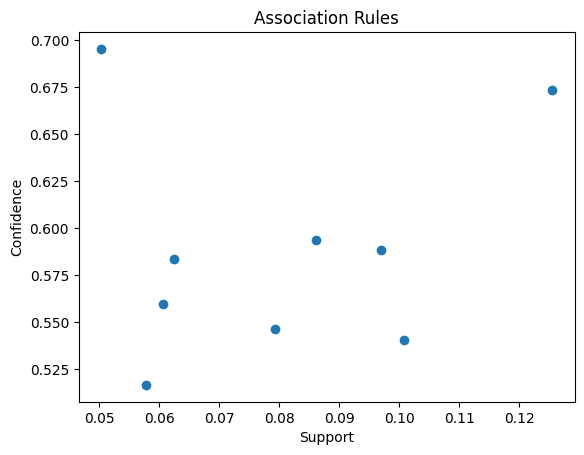

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules")
plt.show()

In [ ]:
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

In [ ]:
movies.head(2)

,movie_id,original_title,title,overview,genres,keywords,cast,crew,vote_average,vote_count,revenue,tags
0,19995,Avatar,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver, ...",[JamesCameron],7.2,11800,2787965087,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley, Ste...",[GoreVerbinski],6.9,4500,961000000,"[Captain, Barbossa,, long, believed, to, be, d..."


In [ ]:
movies.iloc[0]['tags']

['In',
 'the',
 '22nd',
 'century,',
 'a',
 'paraplegic',
 'Marine',
 'is',
 'dispatched',
 'to',
 'the',
 'moon',
 'Pandora',
 'on',
 'a',
 'unique',
 'mission,',
 'but',
 'becomes',
 'torn',
 'between',
 'following',
 'orders',
 'and',
 'protecting',
 'an',
 'alien',
 'civilization.',
 'Action',
 'Adventure',
 'Fantasy',
 'ScienceFiction',
 'cultureclash',
 'future',
 'spacewar',
 'spacecolony',
 'society',
 'spacetravel',
 'futuristic',
 'romance',
 'space',
 'alien',
 'tribe',
 'alienplanet',
 'cgi',
 'marine',
 'soldier',
 'battle',
 'loveaffair',
 'antiwar',
 'powerrelations',
 'mindandsoul',
 '3d',
 'SamWorthington',
 'ZoeSaldana',
 'SigourneyWeaver',
 'StephenLang',
 'JamesCameron']

In [ ]:
new_movies = movies[['movie_id','title','tags']]

In [ ]:
new_movies.head(2)

,movie_id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."


In [ ]:
new_movies["tags"] = new_movies["tags"].apply(lambda x:" ".join(x))
new_movies.head()

,movie_id,title,tags
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,206647,Spectre,A cryptic message from Bond’s past sends him o...
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...
4,49529,John Carter,"John Carter is a war-weary, former military ca..."


In [ ]:
new_movies.iloc[0]['tags']

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. Action Adventure Fantasy ScienceFiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d SamWorthington ZoeSaldana SigourneyWeaver StephenLang JamesCameron'

In [ ]:
new_movies['tags'] = new_movies['tags'].apply(lambda x:x.lower())

In [ ]:
new_movies.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


In [ ]:
new_movies['tags'][0]

'in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver stephenlang jamescameron'

## Classification on Vote_average

In [ ]:
movies['label'] = movies['vote_average'].apply(lambda x: 1 if x >= 7 else 0)

movies[['title','vote_average','tags','label']].head()

,title,vote_average,tags,label
0,Avatar,7.2,"[In, the, 22nd, century,, a, paraplegic, Marin...",1
1,Pirates of the Caribbean: At World's End,6.9,"[Captain, Barbossa,, long, believed, to, be, d...",0
2,Spectre,6.3,"[A, cryptic, message, from, Bond’s, past, send...",0
3,The Dark Knight Rises,7.6,"[Following, the, death, of, District, Attorney...",1
4,John Carter,6.1,"[John, Carter, is, a, war-weary,, former, mili...",0


In [ ]:
from sklearn.model_selection import train_test_split

X = vector # Use the vectorized data
y = movies['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (3844, 5000)
X_test : (962, 5000)


## Classification using SVM

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = svm.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, y_pred))

SVM Accuracy: 0.7193347193347194


In [ ]:
total = len(y_test)
correct = (y_pred == y_test).sum()
wrong = total - correct

print(f"Total predictions : {total}")
print(f"Correct           : {correct}")
print(f"Wrong             : {wrong}")
print(f"Accuracy          : {correct/total*100:.2f}%")

Total predictions : 962
Correct           : 692
Wrong             : 270
Accuracy          : 71.93%


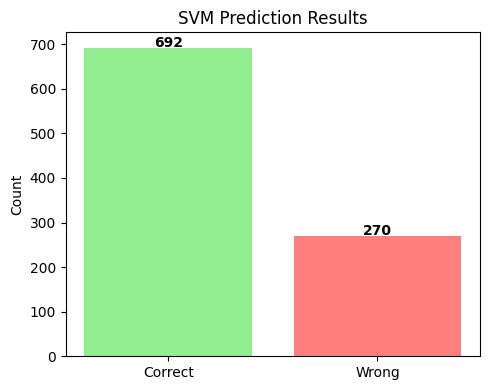

In [ ]:
plt.figure(figsize=(5,4))
plt.bar(['Correct', 'Wrong'], [correct, wrong], color=['#90EE90', '#FF7F7F'])
for i, val in enumerate([correct, wrong]):
    plt.text(i, val + 1, str(val), ha='center', fontweight='bold')
plt.title('SVM Prediction Results')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Classification using NAIVE BAYES

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6361746361746362


In [ ]:
total = len(y_test)
correct = (y_pred_nb == y_test).sum()
wrong = total - correct

print(f"Total predictions : {total}")
print(f"Correct           : {correct}")
print(f"Wrong             : {wrong}")
print(f"Accuracy          : {correct/total*100:.2f}%")

Total predictions : 962
Correct           : 612
Wrong             : 350
Accuracy          : 63.62%


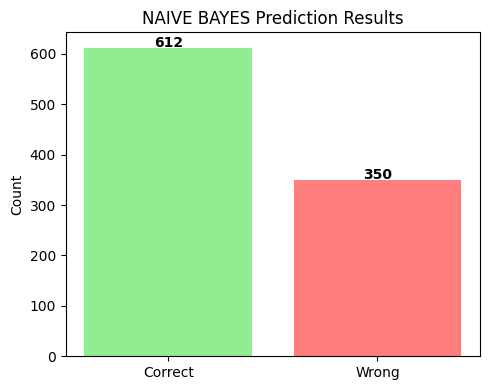

In [ ]:
plt.figure(figsize=(5,4))
plt.bar(['Correct', 'Wrong'], [correct, wrong], color=['#90EE90', '#FF7F7F'])
for i, val in enumerate([correct, wrong]):
    plt.text(i, val + 1, str(val), ha='center', fontweight='bold')
plt.title('NAIVE BAYES Prediction Results')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Clustering using KMeans

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

In [ ]:
movies['cluster'] = clusters

movies[['title','cluster']].head()

,title,cluster
0,Avatar,4
1,Pirates of the Caribbean: At World's End,4
2,Spectre,4
3,The Dark Knight Rises,4
4,John Carter,3


In [ ]:
movies['cluster'].value_counts()

,count
cluster,
0,2188
4,1565
3,820
1,232
2,1


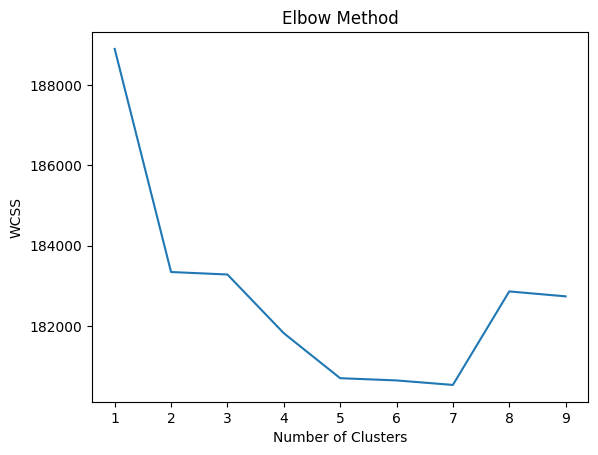

In [ ]:
wcss = []
for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

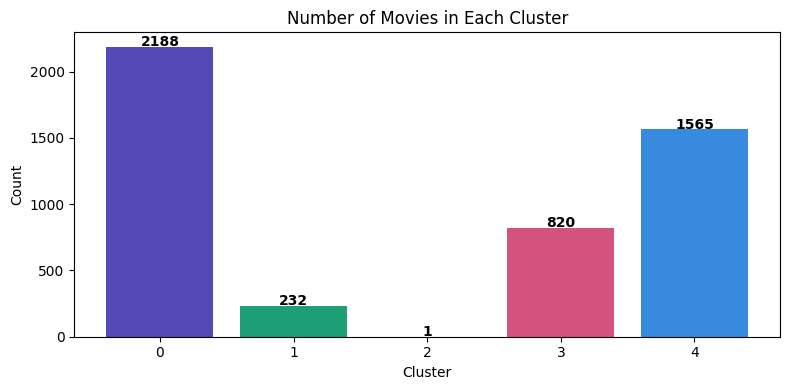

In [ ]:
cluster_counts = movies['cluster'].value_counts().sort_index()

colors = ['#534AB7','#1D9E75','#D85A30','#D4537E','#378ADD']

plt.figure(figsize=(8,4))
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors)
for bar, val in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontweight='bold')
plt.title('Number of Movies in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(range(5))
plt.tight_layout()
plt.show()

In [ ]:
print("Sample movies from each cluster:\n")
for i in range(5):
    movies_in_cluster = movies[movies['cluster'] == i]['title'].values[:5]
    print(f"Cluster {i}: {list(movies_in_cluster)}")

Sample movies from each cluster:

Cluster 0: ['Harry Potter and the Half-Blood Prince', 'The Chronicles of Narnia: Prince Caspian', 'The Hobbit: The Desolation of Smaug', 'Titanic', 'Alice in Wonderland']
Cluster 1: ['The Amazing Spider-Man', 'A Christmas Carol', 'Hugo', 'Iron Man 2', 'Kung Fu Panda 2']
Cluster 2: ['The Green Hornet']
Cluster 3: ['John Carter', 'Superman Returns', 'Quantum of Solace', 'Pirates of the Caribbean: On Stranger Tides', 'Men in Black 3']
Cluster 4: ['Avatar', "Pirates of the Caribbean: At World's End", 'Spectre', 'The Dark Knight Rises', 'Spider-Man 3']


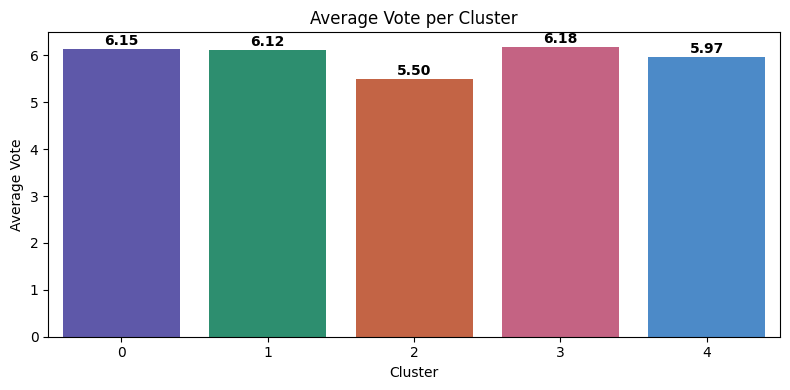

In [ ]:
cluster_avg = movies.groupby('cluster')['vote_average'].mean().reset_index()
cluster_avg.columns = ['Cluster', 'Avg Vote']

plt.figure(figsize=(8,4))
bars = sns.barplot(data=cluster_avg, x='Cluster', y='Avg Vote', palette=colors)
for bar, val in zip(bars.patches, cluster_avg['Avg Vote']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
plt.title('Average Vote per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Vote')
plt.tight_layout()
plt.show()

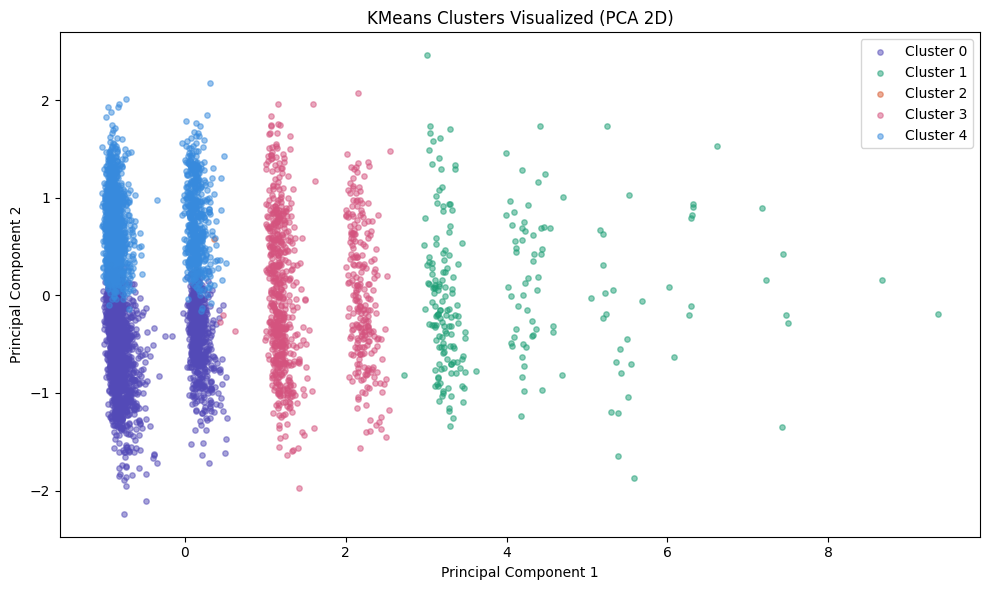

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': movies['cluster'].astype(str)
})

plt.figure(figsize=(10,6))
for i, color in zip(['0','1','2','3','4'], colors):
    subset = pca_df[pca_df['Cluster'] == i]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {i}',
                color=color, alpha=0.5, s=15)

plt.title('KMeans Clusters Visualized (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

## Clustering using Hierarchical

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(X[:100], method='ward')

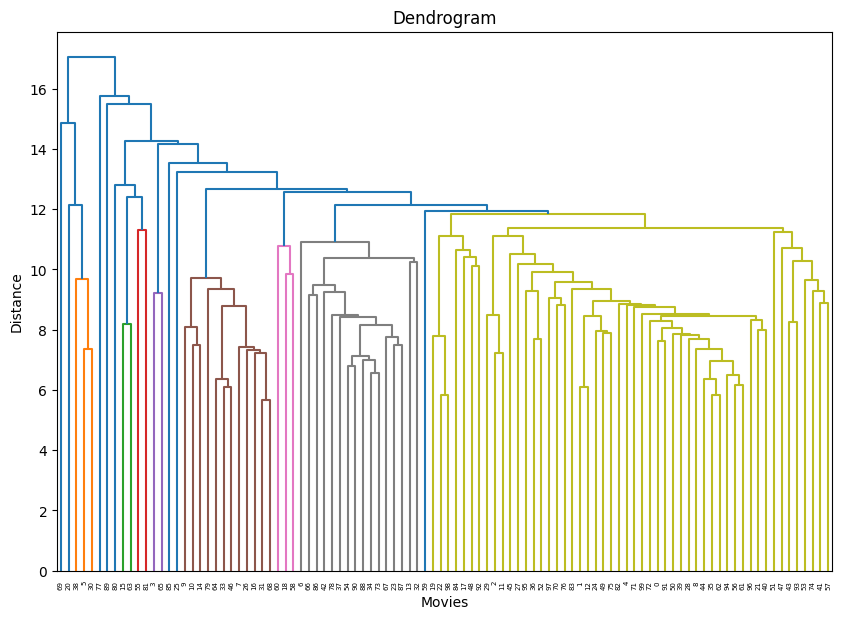

In [ ]:
plt.figure(figsize=(10,7))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Movies")
plt.ylabel("Distance")
plt.show()

In [ ]:
from scipy.cluster.hierarchy import fcluster

# Cut tree into 5 clusters (same as KMeans for comparison)
hier_clusters = fcluster(linked, t=5, criterion='maxclust')

# Add to dataframe (only 100 movies since we used X[:100])
movies_hier = movies.iloc[:100].copy()
movies_hier['hier_cluster'] = hier_clusters

movies_hier[['title', 'hier_cluster']].head(10)

,title,hier_cluster
0,Avatar,3
1,Pirates of the Caribbean: At World's End,3
2,Spectre,3
3,The Dark Knight Rises,3
4,John Carter,3
5,Spider-Man 3,1
6,Tangled,3
7,Avengers: Age of Ultron,3
8,Harry Potter and the Half-Blood Prince,3
9,Batman v Superman: Dawn of Justice,3


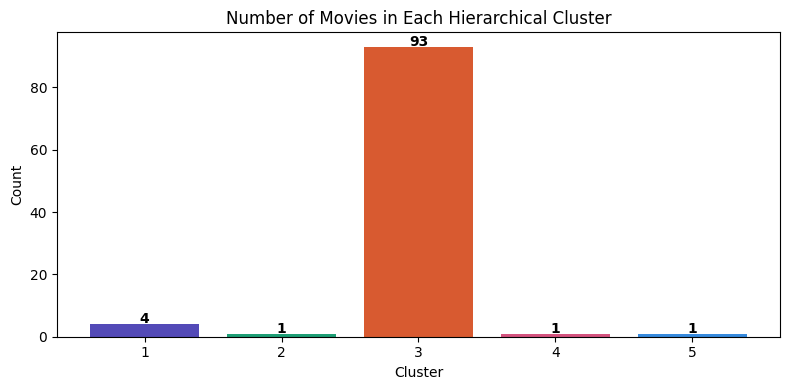

In [ ]:
cluster_counts = movies_hier['hier_cluster'].value_counts().sort_index()

colors = ['#534AB7','#1D9E75','#D85A30','#D4537E','#378ADD']

plt.figure(figsize=(8,4))
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors)
for bar, val in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontweight='bold')
plt.title('Number of Movies in Each Hierarchical Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
print("Sample movies from each Hierarchical cluster:\n")
for i in sorted(movies_hier['hier_cluster'].unique()):
    movies_in_cluster = movies_hier[movies_hier['hier_cluster'] == i]['title'].values[:5]
    print(f"Cluster {i}: {list(movies_in_cluster)}")

Sample movies from each Hierarchical cluster:

Cluster 1: ['Spider-Man 3', 'The Amazing Spider-Man', 'Spider-Man 2', 'The Amazing Spider-Man 2']
Cluster 2: ['Hugo']
Cluster 3: ['Avatar', "Pirates of the Caribbean: At World's End", 'Spectre', 'The Dark Knight Rises', 'John Carter']
Cluster 4: ['Wreck-It Ralph']
Cluster 5: ['Inside Out']


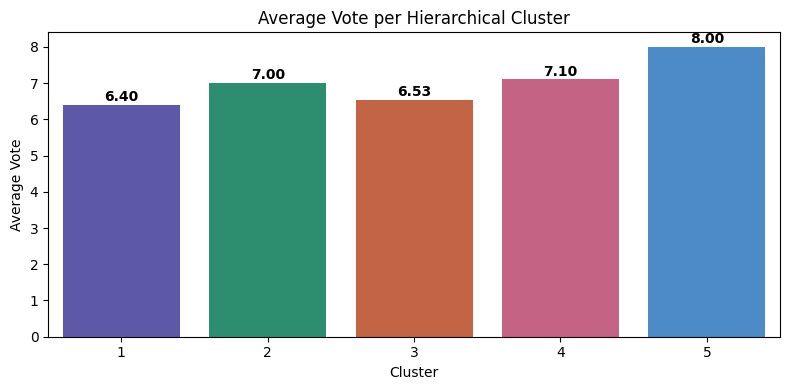

In [ ]:
cluster_avg = movies_hier.groupby('hier_cluster')['vote_average'].mean().reset_index()
cluster_avg.columns = ['Cluster', 'Avg Vote']

plt.figure(figsize=(8,4))
bars = sns.barplot(data=cluster_avg, x='Cluster', y='Avg Vote', palette=colors)
for bar, val in zip(bars.patches, cluster_avg['Avg Vote']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
plt.title('Average Vote per Hierarchical Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Vote')
plt.tight_layout()
plt.show()

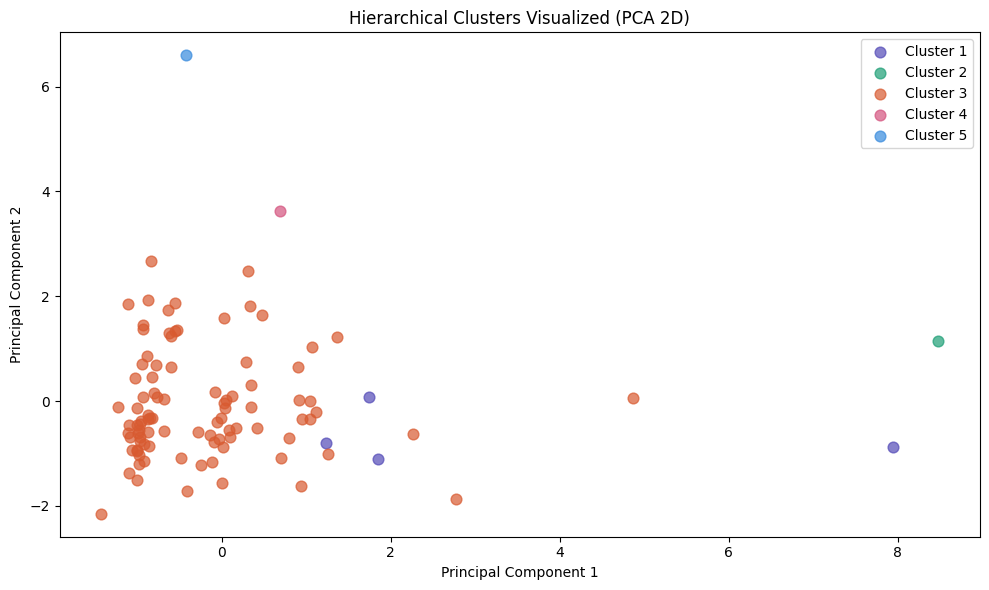

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X[:100])  # only 100 movies same as hierarchical

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': movies_hier['hier_cluster'].astype(str)
})

plt.figure(figsize=(10,6))
for i, color in zip(sorted(pca_df['Cluster'].unique()), colors):
    subset = pca_df[pca_df['Cluster'] == i]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {i}',
                color=color, alpha=0.7, s=60)

plt.title('Hierarchical Clusters Visualized (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 40)
print("   KMeans vs Hierarchical Comparison")
print("=" * 40)
print(f"\nKMeans (all 4800 movies):")
print(movies['cluster'].value_counts().sort_index().to_string())

print(f"\nHierarchical (100 movies sample):")
print(movies_hier['hier_cluster'].value_counts().sort_index().to_string())

   KMeans vs Hierarchical Comparison

KMeans (all 4800 movies):
cluster
0    2188
1     232
2       1
3     820
4    1565

Hierarchical (100 movies sample):
hier_cluster
1     4
2     1
3    93
4     1
5     1


## Stemming using NLTK (Natural Language Processing)

In [ ]:
import nltk
from nltk.stem import PorterStemmer
ps = PorterStemmer()

## Stem each word in tags to its root form
### **Example: "actions" → "action", "running" → "run"**

In [ ]:
def stems(text):
  l = []
  for i in text.split():
    l.append(ps.stem(i))
  return " ".join(l)

In [ ]:
new_movies['tags'] = new_movies['tags'].apply(stems)

In [ ]:
new_movies.iloc[0]['tags']

'in the 22nd century, a parapleg marin is dispatch to the moon pandora on a uniqu mission, but becom torn between follow order and protect an alien civilization. action adventur fantasi sciencefict cultureclash futur spacewar spacecoloni societi spacetravel futurist romanc space alien tribe alienplanet cgi marin soldier battl loveaffair antiwar powerrel mindandsoul 3d samworthington zoesaldana sigourneyweav stephenlang jamescameron'

## Vectorization (Text → Numbers)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000, stop_words='english')

In [ ]:
vector = cv.fit_transform(new_movies['tags']).toarray()

In [ ]:
vector

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
vector.shape

(4806, 5000)

## Cosine Similarity (Finding Similar Movies)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(vector)
similarity

array([[1.        , 0.08458258, 0.08585457, ..., 0.04559608, 0.        ,
        0.        ],
       [0.08458258, 1.        , 0.05970814, ..., 0.02378257, 0.        ,
        0.02615329],
       [0.08585457, 0.05970814, 1.        , ..., 0.02414023, 0.        ,
        0.        ],
       ...,
       [0.04559608, 0.02378257, 0.02414023, ..., 1.        , 0.03962144,
        0.04229549],
       [0.        , 0.        , 0.        , ..., 0.03962144, 1.        ,
        0.08714204],
       [0.        , 0.02615329, 0.        , ..., 0.04229549, 0.08714204,
        1.        ]])

In [ ]:
similarity.shape

(4806, 4806)

## Recommendation Function

In [ ]:
def recommend(movie):
  index = new_movies[new_movies['title'] == movie].index[0]
  distances = sorted(list(enumerate(similarity[index])), reverse=True, key=lambda x:x[1])
  for i in distances[1:6]:
    print(new_movies.iloc[i[0]].title)

## Display first 30 movie titles — pick any title from here to test recommend()

In [ ]:
display(new_movies['title'].head(30))

,title
0,Avatar
1,Pirates of the Caribbean: At World's End
2,Spectre
3,The Dark Knight Rises
4,John Carter
5,Spider-Man 3
6,Tangled
7,Avengers: Age of Ultron
8,Harry Potter and the Half-Blood Prince
9,Batman v Superman: Dawn of Justice


In [ ]:
print(recommend('Jurassic World'))

Jurassic Park
The Lost World: Jurassic Park
Walking With Dinosaurs
Terminator Genisys
Jurassic Park III
None


In [ ]:
print(recommend('Spider-Man 3'))

Spider-Man 2
Spider-Man
The Amazing Spider-Man 2
The Amazing Spider-Man
Arachnophobia
None


In [ ]:
print(recommend('The Dark Knight Rises'))

The Dark Knight
Batman Returns
Batman
Batman Forever
Batman Begins
None


In [ ]:
import pickle

pickle.dump(movies, open('movies.pkl','wb'))
pickle.dump(similarity, open('similarity.pkl','wb'))

## Research Paper 1 :
##### Title   : Movie Recommendation and Sentiment Analysis Using Machine Learning
##### Methods : Cosine Similarity + SVM + Naive Bayes (same as our project)
##### Source  : ScienceDirect, Procedia Computer Science, 2022
##### Link    : https://www.sciencedirect.com/science/article/pii/S2666285X22000176

## Research Paper 2 :
##### Title   : Improving Movie Recommendation Systems Filtering by Exploiting User-Based Reviews
##### Methods : KMeans Clustering + Hierarchical + Naive Bayes (same as our project)
##### Source  : PMC (PubMed Central), 2020
##### Link    : https://pmc.ncbi.nlm.nih.gov/articles/PMC7256369/